Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Train: (50000, 64, 64, 3) | Test: (10000, 64, 64, 3)

Loading ResNet50 with ImageNet weights...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Total base layers: 175
All base layers frozen.
Total layers: 179 | Trainable: 4

--- Phase 1: Training Head Only (Base Frozen) ---
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.2294 - loss: 2.0820 - val_accuracy: 0.2992 - val_loss: 1.9240
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.2947 - loss: 1.9158 - val_accuracy: 0.3129 - val_loss: 1.8649
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.3143 - loss: 1.8665 - val_accuracy: 0.3365 - val_loss: 1.8308
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.3309 - loss: 1.8382 - val_accuracy: 0.3420 - val_loss: 1.8014
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.3352 - loss: 1.8170 - val_accuracy: 0.3579 - val_loss: 1.

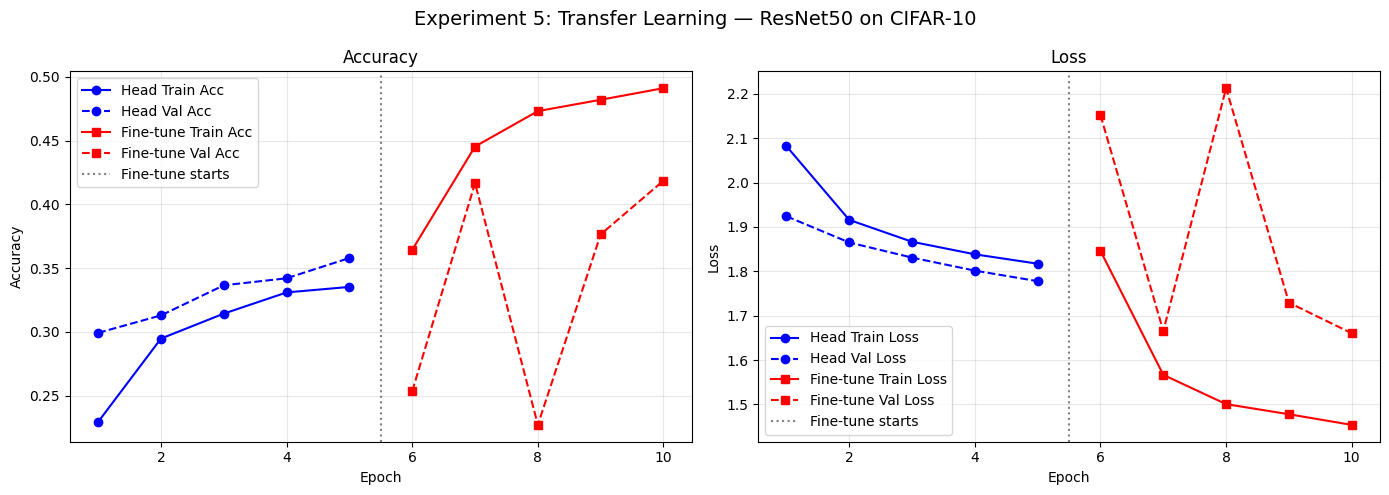


            RESULT SUMMARY
  Head-only  Val Accuracy : 35.79%
  Fine-tuned Val Accuracy : 41.86%
  Improvement             : +6.07%
  Final Test Accuracy     : 41.86%


In [1]:
# Experiment 5: Transfer Learning using Pre-trained CNN (ResNet50)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# ── 1. Load Dataset ──────────────────────────────────────────
print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = tf.image.resize(x_train, (64, 64)).numpy() / 255.0
x_test  = tf.image.resize(x_test,  (64, 64)).numpy() / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print(f"Train: {x_train.shape} | Test: {x_test.shape}")

# ── 2. Load Pre-trained ResNet50 ─────────────────────────────
print("\nLoading ResNet50 with ImageNet weights...")
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
print(f"Total base layers: {len(base_model.layers)}")

# ── 3. Freeze Base Layers ────────────────────────────────────
base_model.trainable = False
print(f"All base layers frozen.")

# ── 4. Add Custom Classifier Head ───────────────────────────
x      = GlobalAveragePooling2D()(base_model.output)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.4)(x)
output = Dense(10, activation='softmax')(x)
model  = Model(inputs=base_model.input, outputs=output)

total      = sum(1 for l in model.layers)
trainable  = sum(1 for l in model.layers if l.trainable)
print(f"Total layers: {total} | Trainable: {trainable}")

# ── 5. Train Classifier Head Only ────────────────────────────
print("\n--- Phase 1: Training Head Only (Base Frozen) ---")
model.compile(optimizer=Adam(0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_head = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

# ── 6. Fine-tune Last 20 Layers ──────────────────────────────
print("\n--- Phase 2: Fine-tuning Last 20 Layers ---")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_ft = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

# ── 7. Evaluate ──────────────────────────────────────────────
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy : {acc*100:.2f}%")
print(f"Final Test Loss     : {loss:.4f}")

# ── 8. Plot Results ──────────────────────────────────────────
head_train_acc = history_head.history['accuracy']
head_val_acc   = history_head.history['val_accuracy']
head_train_loss= history_head.history['loss']
head_val_loss  = history_head.history['val_loss']

ft_train_acc   = history_ft.history['accuracy']
ft_val_acc     = history_ft.history['val_accuracy']
ft_train_loss  = history_ft.history['loss']
ft_val_loss    = history_ft.history['val_loss']

epochs1 = range(1, 6)
epochs2 = range(6, 11)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experiment 5: Transfer Learning — ResNet50 on CIFAR-10', fontsize=14)

# Accuracy plot
axes[0].plot(epochs1, head_train_acc, 'b-o', label='Head Train Acc')
axes[0].plot(epochs1, head_val_acc,   'b--o', label='Head Val Acc')
axes[0].plot(epochs2, ft_train_acc,   'r-s', label='Fine-tune Train Acc')
axes[0].plot(epochs2, ft_val_acc,     'r--s', label='Fine-tune Val Acc')
axes[0].axvline(x=5.5, color='gray', linestyle=':', linewidth=1.5, label='Fine-tune starts')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(epochs1, head_train_loss, 'b-o', label='Head Train Loss')
axes[1].plot(epochs1, head_val_loss,   'b--o', label='Head Val Loss')
axes[1].plot(epochs2, ft_train_loss,   'r-s', label='Fine-tune Train Loss')
axes[1].plot(epochs2, ft_val_loss,     'r--s', label='Fine-tune Val Loss')
axes[1].axvline(x=5.5, color='gray', linestyle=':', linewidth=1.5, label='Fine-tune starts')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 9. Summary ───────────────────────────────────────────────
print("\n" + "="*42)
print("            RESULT SUMMARY")
print("="*42)
print(f"  Head-only  Val Accuracy : {max(head_val_acc)*100:.2f}%")
print(f"  Fine-tuned Val Accuracy : {max(ft_val_acc)*100:.2f}%")
print(f"  Improvement             : +{(max(ft_val_acc)-max(head_val_acc))*100:.2f}%")
print(f"  Final Test Accuracy     : {acc*100:.2f}%")
print("="*42)